In [ ]:
# Name: Nimotallahi Abiodun Durojaiye
# WTF ID: WTF/2025/5891
# MAIL: nimotallahi02@outlook.com

In [ ]:
import pandas as pd
import numpy as np

**Question 1: Exploratory Data Analysis (EDA) to figure out which variables have direct and clear impact on employee retention.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive/Colab Notebooks//HR_comma_sep 1.csv"
file_path = "/content/drive/My Drive/Colab Notebooks/HR_comma_sep 1.csv"

# Load dataset
df = pd.read_csv(file_path)

# Display first few rows
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/My Drive/Colab Notebooks//HR_comma_sep 1.csv'
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3       

In [ ]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Correlation with retention
corr = numeric_cols.corr()['left'].sort_values(ascending=False)
print(corr)




left                     1.000000
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64


**Correlation with Numeric Variables**

Satisfaction level (-0.388) → This is the strongest predictor. Employees with lower satisfaction are much more likely to leave.

Work accident (-0.154) → Negative correlation means employees who had a work accident are less likely to leave (perhaps due to compensation or job security).

Promotion in last 5 years (-0.062) → Slight negative correlation; promotions help retention but the effect is small.

Time spent at company (+0.145) → Longer tenure slightly increases likelihood of leaving (possibly burnout or plateauing).

Average monthly hours (+0.071) → Higher hours correlate with leaving, but weakly.

Number of projects (+0.024) and last evaluation (+0.007) → Very weak correlations, not strong predictors.

Hence, satisfaction level is the most critical driver of retention, followed by tenure and work accidents.

In [ ]:
print(df.groupby('Department')['left'].mean())


Department
IT             0.222494
RandD          0.153748
accounting     0.265971
hr             0.290934
management     0.144444
marketing      0.236597
product_mng    0.219512
sales          0.244928
support        0.248991
technical      0.256250
Name: left, dtype: float64


**Department vs Retention**

Highest attrition: HR (29%), Technical (25.6%), Support (24.9%), Sales (24.5%).

Lowest attrition: R&D (15%), Management (14.4%).

Thus, Departments like HR, technical, and support face higher turnover, while management and R&D are more stable.

In [ ]:
print(df.groupby('salary')['left'].mean())

salary
high      0.066289
low       0.296884
medium    0.204313
Name: left, dtype: float64


**Salary vs Retention**

Low salary: 29.7% attrition — highest risk group.

Medium salary: 20.4% attrition.

High salary: Only 6.6% attrition — very stable.

Hence, Salary has a clear impact: higher pay strongly reduces turnover.

**Question 2:Plot bar charts showing impact of employee salaries on retention.**

In [ ]:
# Rename the column
df = df.rename(columns={'left': 'Proportion of Employees that Left'})

# Verify
print(df.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  Proportion of Employees that Left  \
0                   3              0                                  1   
1                   6              0                                  1   
2                   4              0                                  1   
3                   5              0                                  1   
4                   3              0                                  1   

   promotion_last_5years Department  salary  
0                     

In [ ]:
# Rename the column
df = df.rename(columns={'Proportion of Employees Leaving': 'Proportion of Employees that Left'})

# Verify
print(df.head())

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  Proportion of Employees that Left  \
0                   3              0                                  1   
1                   6              0                                  1   
2                   4              0                                  1   
3                   5              0                                  1   
4                   3              0                                  1   

   promotion_last_5years Department  salary  
0                     

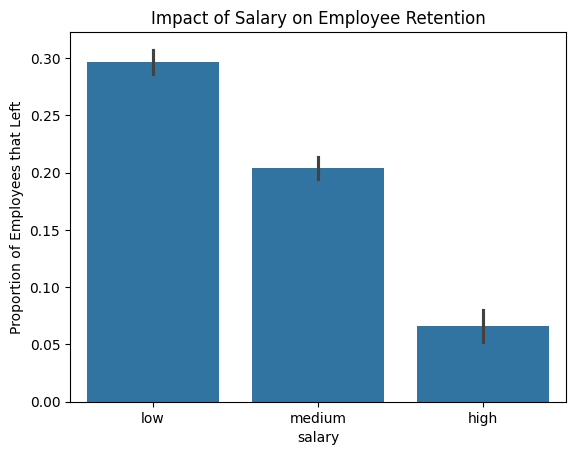

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Salary vs retention
sns.barplot(x='salary', y='Proportion of Employees that Left', data=df, estimator=np.mean)
plt.title("Impact of Salary on Employee Retention")
plt.show()




Impact of Employees Salary on Retention

The vertical axis represents the proportion of employees who left the company, while the horizontal axis categorizes them into low, medium, and high salary groups.

Low salary group: Nearly 30% of employees left. This is the highest attrition rate, suggesting that low pay is strongly linked to turnover.

Medium salary group: Around 20% attrition. This is lower than the low salary group but still significant.

High salary group: Only about 7% attrition. Employees with higher salaries are far more likely to stay.

The error bars on each bar represent variability or confidence intervals, but the overall trend is clear: the higher the salary, the lower the likelihood of employees leaving.

This visualization confirms that salary is a direct and strong factor in retention, making it one of the key variables to include in your predictive model.

**Question 3: Plot bar charts showing corelation between department and employee retention.**

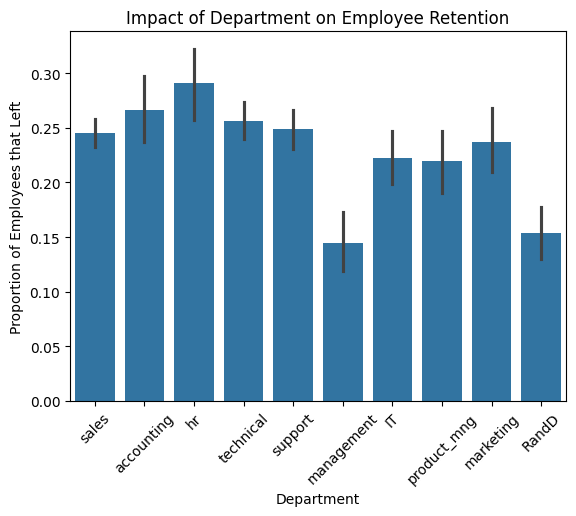

In [ ]:


# Department vs retention
sns.barplot(x='Department',
            y='Proportion of Employees that Left',
            data=df,
            estimator=np.mean)

plt.title("Impact of Department on Employee Retention")
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()


This chart illustrates how employee retention varies across departments. The vertical axis shows the proportion of employees who left, while the horizontal axis lists the different departments.

Highest attrition: HR has the largest proportion of employees leaving (close to 30%), followed by accounting and technical. These departments appear to struggle most with retention.

Moderate attrition: Sales, support, and marketing show turnover rates around 24–25%, which is significant but not as high as HR.

Lowest attrition: Management (about 14%) and R&D (around 15%) have the lowest turnover, suggesting stronger stability in these areas.

The error bars indicate variability, but the overall pattern is clear: retention challenges are concentrated in HR, accounting, and technical departments, while management and R&D are relatively stable.

This insight suggests that targeted retention strategies (e.g., better career development, workload management, or compensation adjustments) may be most urgently needed in HR and technical roles.

Question 4: Logistic Regression Model using variables that were narrowed down in step 1

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Features and target
X = df[['satisfaction_level','time_spend_company',
        'Work_accident','promotion_last_5years',
        'salary','Department']]
y = df['Proportion of Employees that Left']   # renamed column

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Build model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)




**Question 5: Measure the accuracy of the model.**

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.7611111111111111
Confusion Matrix:
 [[3158  270]
 [ 805  267]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.92      0.85      3428
           1       0.50      0.25      0.33      1072

    accuracy                           0.76      4500
   macro avg       0.65      0.59      0.59      4500
weighted avg       0.73      0.76      0.73      4500



The model is very good at predicting who stays (92% recall for class 0).

It struggles with predicting who leaves (only 25% recall for class 1).

**Classification Report:**

Stayed (0): Precision 0.80, Recall 0.92, F1 0.85 → strong performance.

Left (1): Precision 0.50, Recall 0.25, F1 0.33 → weak performance.

Weighted average F1: 0.73 → overall balanced score.

Thus, the dataset is imbalanced: ~76% stayed, ~24% left.

Logistic regression tends to favor the majority class (predicting “stay” more often).

That’s why recall for “left” is low — the model misses many employees who actually leave.